# EDA & Visualization: Employee Attrition

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = "../data/employee_attrition_2026_master.csv"
df = pd.read_csv(data)
df.head()

,employee_id,age,generation,gender,department,job_level,is_manager,tenure_years,salary_usd,salary_vs_market_pct,...,burnout_score,manager_relationship_score,manager_1on1_per_month,engagement_score,promotions_last_2y,career_growth_score,recent_layoff_round,team_size,attrition_reason,attrition
0,EMP000000,26,Gen Z,Female,Marketing,Junior,0,5.5,70000,5.2,...,3.6,2,0,62,0,2,0,22,stayed,0
1,EMP000001,35,Millennial,Female,Sales,Junior,0,0.5,64000,-15.5,...,4.8,3,2,79,1,2,0,24,stayed,0
2,EMP000002,23,Gen Z,Male,HR,Senior,0,2.0,142000,-15.9,...,10.0,1,2,43,0,4,1,3,poor_management,1
3,EMP000003,20,Gen Z,Female,Sales,Manager,1,2.2,147000,2.6,...,4.3,1,4,64,1,3,0,24,stayed,0
4,EMP000004,40,Millennial,Female,Data,Senior,0,6.0,141000,11.3,...,2.9,1,1,92,0,2,0,5,stayed,0


In [51]:
# ตรวจสอบ Missing Value
print(df.isnull().sum().sum())
df.describe()

0


,age,is_manager,tenure_years,salary_usd,salary_vs_market_pct,rto_mandate,days_in_office_required,commute_minutes,prefers_remote,flexibility_importance,...,after_hours_work,burnout_score,manager_relationship_score,manager_1on1_per_month,engagement_score,promotions_last_2y,career_growth_score,recent_layoff_round,team_size,attrition
count,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,...,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,34.240711,0.242044,3.598353,115385.533333,-1.940573,0.422444,3.000022,35.809444,0.680800,2.994956,...,0.256556,4.820122,2.996000,1.500133,65.723844,0.450867,2.998489,0.236889,13.458911,0.181422
std,8.547373,0.428326,2.545593,50084.707992,9.990708,0.493954,1.578040,25.334550,0.466172,1.415595,...,0.436737,1.964970,1.416469,1.236460,16.718265,0.623320,1.414810,0.425178,6.366689,0.385372
min,20.000000,0.000000,0.100000,35000.000000,-35.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,28.000000,0.000000,1.700000,75000.000000,-8.700000,0.000000,2.000000,17.000000,0.000000,2.000000,...,0.000000,3.400000,2.000000,1.000000,54.000000,0.000000,2.000000,0.000000,8.000000,0.000000
50%,34.000000,0.000000,3.000000,103000.000000,-2.000000,0.000000,3.000000,30.000000,1.000000,3.000000,...,0.000000,4.800000,3.000000,1.000000,66.000000,0.000000,3.000000,0.000000,13.000000,0.000000
75%,40.000000,0.000000,4.800000,146000.000000,4.800000,1.000000,4.000000,48.000000,1.000000,4.000000,...,1.000000,6.200000,4.000000,2.000000,77.000000,1.000000,4.000000,0.000000,19.000000,0.000000
max,64.000000,1.000000,25.000000,345000.000000,35.000000,1.000000,5.000000,180.000000,1.000000,5.000000,...,1.000000,10.000000,5.000000,4.000000,100.000000,2.000000,5.000000,1.000000,24.000000,1.000000


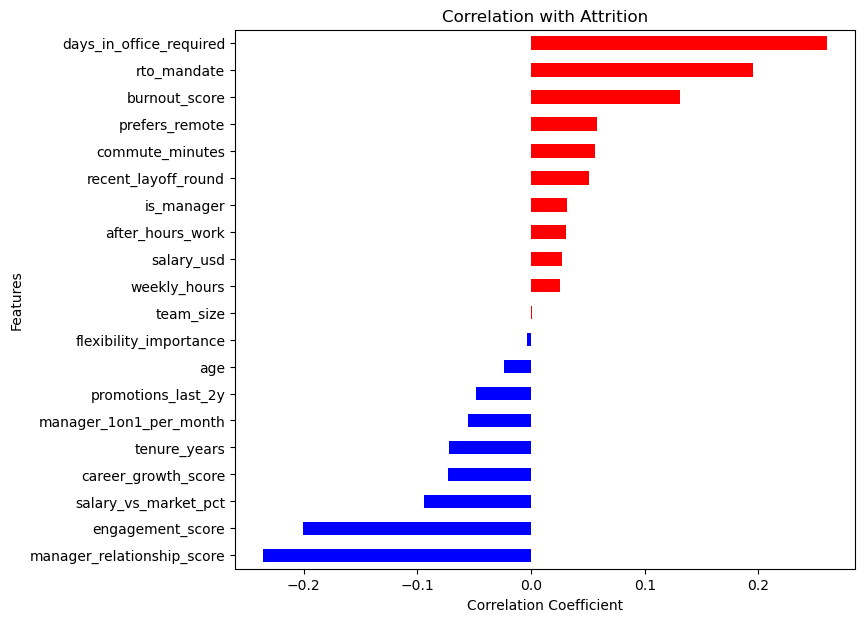

In [64]:
### 10. Correlation bar chart
corr_target = df.corr(numeric_only=True)['attrition'].drop('attrition').sort_values()
corr_target.plot(kind='barh', figsize=(8,7), color=['red' if v>0 else 'blue' for v in corr_target] )
plt.title("Correlation with Attrition")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")

plt.show()


**Insight** 
จากกราฟแสดงได้ว่า ปัจจัยที่ส่งผลต่อการลาออกของพนักงานแบ่งออกเป็น

แท่งสีแดง = ตัวแปรที่ยิ่งสูงยิ่งลาออกเยอะ เช่น work_arrangement_onsite, burnout_score  
แท่งสีน้ำเงิน = ตัวแปรที่ยิ่งสูงยิ่งลาออกน้อย เช่น manager_relationship_score, engagement_score


### 1. สัดส่วนพนักงานที่ลาออก (Attrition)

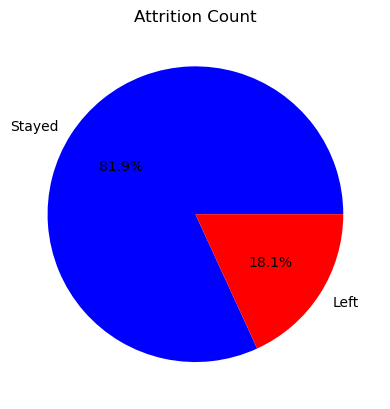

จำนวนพนักงานที่ไม่ลาออก 36836 คน
จำนวนพนักงานที่ลาออก 8164 คน


In [52]:
attr_counts = df['attrition'].value_counts().sort_index()
df['attrition'].value_counts().plot(kind='pie', labels=['Stayed','Left'], colors=['blue','red'], autopct='%1.1f%%')
plt.title("Attrition Count")
plt.ylabel('')
plt.show()
print(f"จำนวนพนักงานที่ไม่ลาออก {attr_counts[0]} คน")
print(f"จำนวนพนักงานที่ลาออก {attr_counts[1]} คน")


**Insight:** พนักงานส่วนใหญ่ยังอยู่ 35,508 คน (attrition=0)
มีคนลาออก 7,931 คน (attrition=1)
 เป็นส่วนน้อย ข้อมูลจึงไม่สมดุล (imbalanced)

### 2. Age กับ Attrition

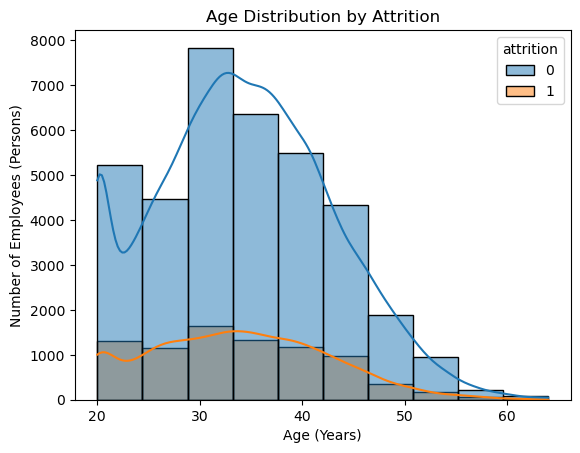

In [53]:
sns.histplot(data=df, x='age', hue='attrition', bins=10, kde=True,)

plt.title("Age Distribution by Attrition")
plt.xlabel("Age (Years)")
plt.ylabel("Number of Employees (Persons)")
plt.show()


**Insight:** การกระจายอายุของคนที่ลาออกกับคนที่อยู่ต่อคล้ายกัน อายุจึงไม่ใช่ปัจจัยหลักที่แยกสองกลุ่มนี้ได้ชัดเจน

### 3. Burnout Score กับ Attrition

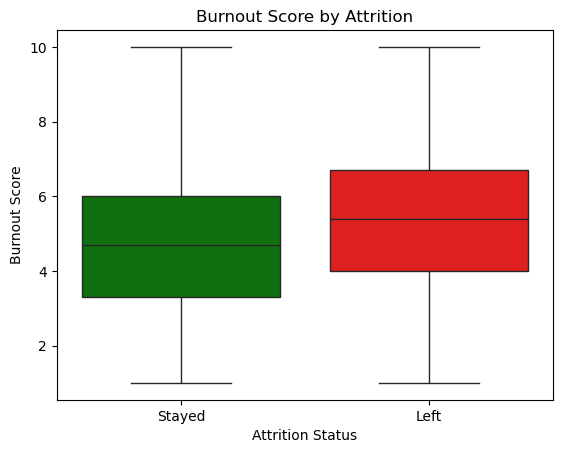

In [54]:
sns.boxplot(x='attrition', y='burnout_score', data=df, hue='attrition', palette=['green','red'], legend=False)

plt.title("Burnout Score by Attrition")
plt.xticks([0, 1], ["Stayed", "Left"])
plt.xlabel("Attrition Status")
plt.ylabel("Burnout Score")
plt.show()

**Insight:** กลุ่มที่ลาออกมีค่า burnout_score สูงกว่ากลุ่มที่อยู่ต่ออย่างเห็นได้ชัด แสดงว่ายิ่งหมดไฟ ยิ่งมีโอกาสลาออกสูง

### 4. Engagement Score ( คะแนนความผูกพันธ์ ) กับ Attrition

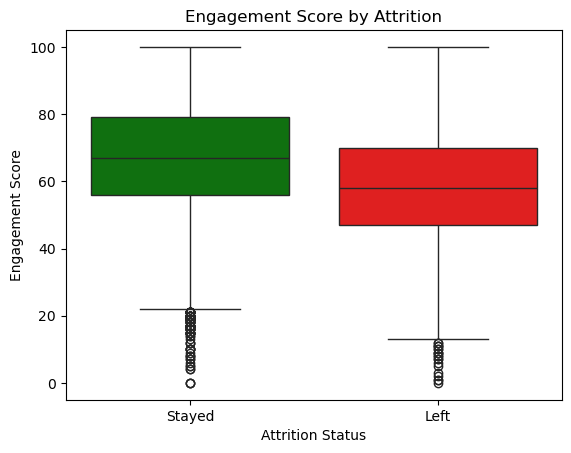

In [55]:
sns.boxplot(x='attrition', y='engagement_score', data=df, hue='attrition', palette=['green','red'], legend=False)

plt.title("Engagement Score by Attrition")
plt.xticks([0, 1], ["Stayed", "Left"])
plt.xlabel("Attrition Status")
plt.ylabel("Engagement Score")
plt.show()

**Insight:** กลุ่มที่ลาออกมี engagement_score ต่ำกว่ากลุ่มที่อยู่ต่อชัดเจน ความพึงพอใจ/ความผูกพันกับงานต่ำ สัมพันธ์กับการลาออกสูง

### 5. Work Arrangement กับ Attrition

In [56]:
# df['work_arrangement'] = np.select(
#     [df['work_arrangement_onsite'], df['work_arrangement_remote']],
#     ['onsite', 'remote'],
#     default='hybrid'
# )

# df.groupby('work_arrangement')['attrition'].mean().plot(kind='bar', color=['orange','green','blue'])

# plt.title("Attrition Rate by Work Arrangement")
# plt.xlabel("Work Arrangement")
# plt.xticks(rotation=0)
# plt.ylabel("Attrition Rate (%)")
# plt.show()

**Insight:** พนักงานที่ทำงาน onsite มีอัตราการลาออกสูงกว่าคนที่ทำงาน hybrid, remote ชัดเจน

### 6.Tenure (อายุงาน) กับ Attrition 

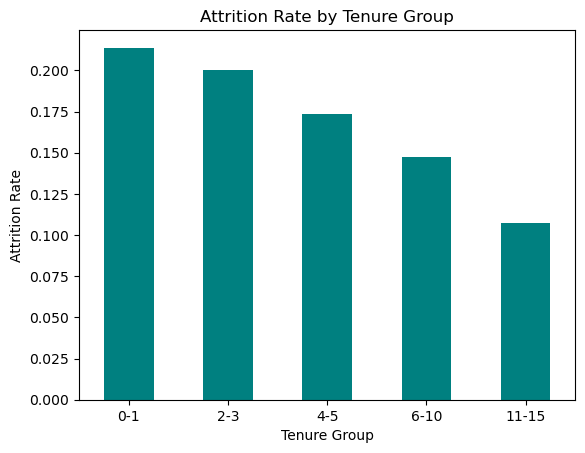

In [57]:
df['tenure_bin'] = pd.cut(df['tenure_years'], bins=[0,1,3,5,10,15],labels=['0-1','2-3','4-5','6-10','11-15'])
df.groupby(df['tenure_bin'], observed=True)['attrition'].mean().plot(kind='bar', color='teal')
plt.title("Attrition Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Attrition Rate")
plt.xticks(rotation=0)
plt.show()

**Insight:** ดูจากช่วยอายุ กลุ่มที่มีอายุงานน้อย มีอัตราการลาออกสูงกว่ากลุ่มคนที่่อายุงานหลายปี

### 7. ค่าตอบแทน Salary vs Market กับ Attrition

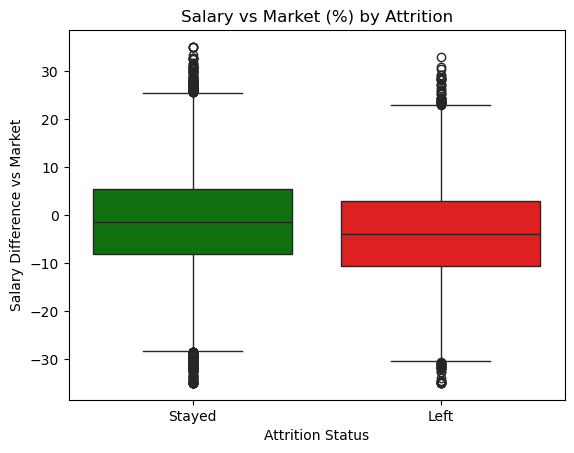

In [58]:
sns.boxplot(x='attrition', y='salary_vs_market_pct', data=df, hue='attrition', palette=['green','red'], legend=False)
plt.title("Salary vs Market (%) by Attrition")
plt.xticks([0, 1], ["Stayed", "Left"])
plt.xlabel("Attrition Status")
plt.ylabel("Salary Difference vs Market")
plt.show()

**Insight:** กลุ่มที่ลาออก มีค่าเงินเดือนเทียบตลาด ต่ำกว่ากลุ่มที่อยู่ต่อ คนที่ได้เงินเดือนต่ำกว่าตลาดมาก มีอัตราลาออกสูงกว่าคนที่ได้เงินเดือนสูงกว่าตลาด

### 8. After-Hours Work  (การทำงานนอกเวลา) กับ Attrition

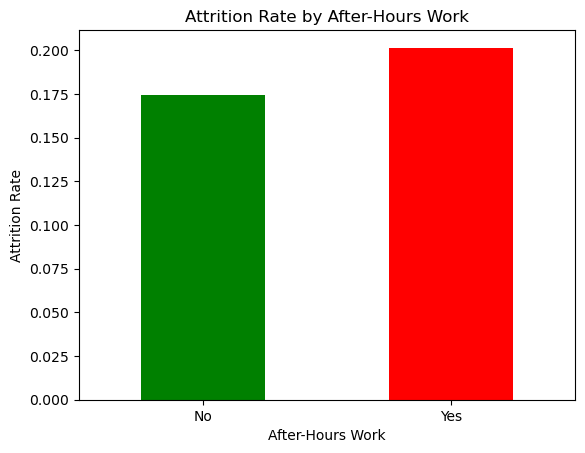

In [59]:
df.groupby('after_hours_work')['attrition'].mean().plot(kind='bar', color=['green','red'])
plt.title("Attrition Rate by After-Hours Work")
plt.xticks([0, 1], ["No", "Yes"], rotation=0)
plt.xlabel("After-Hours Work")
plt.ylabel("Attrition Rate")
plt.show()

**Insight:** พนักงานที่ต้องทำงานนอกเวลาเป็นประจำมีอัตราลาออกสูงกว่าคนที่ไม่ต้องทำงานนอกเวลา  ทำให้เห็นว่า การทำงานนอกเวลา ที่แย่ลงมีผลผลักดันให้ลาออกมากขึ้น 

### 9.  Commute (การเดินทาง) กับ Attrition

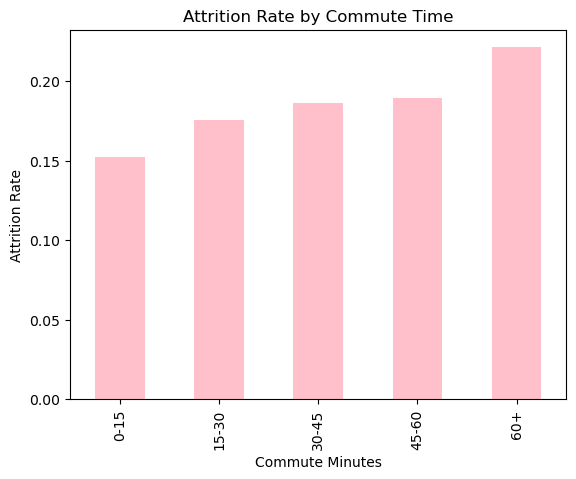

In [60]:
df['commute_bin'] = pd.cut(df['commute_minutes'], bins=[0,15,30,45,60,200],labels=['0-15','15-30','30-45','45-60','60+'])
df.groupby('commute_bin', observed=True)['attrition'].mean().plot(kind='bar', color='pink')
plt.title("Attrition Rate by Commute Time")
plt.ylabel("Attrition Rate")
plt.xlabel("Commute Minutes")
plt.show()

**Insight:** อัตราลาออกเพิ่มขึ้นตามช่วงเวลาเดินทาง กลุ่มที่เดินทางเกิน 60 นาทีมีอัตราลาออกสูงสุด เมื่อเทียบกับกลุ่มที่เดินทางไม่เกิน 15 นาที

## สรุปผล EDA

**ปัจจัยที่สัมพันธ์กับ Attrition**

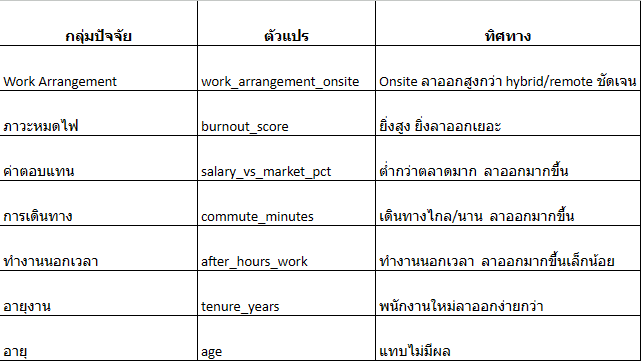
